In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [8]:
df = pd.read_csv("ford.csv")
print(df.head())
print(df.info())


     model  year  price transmission  mileage fuelType  tax   mpg  engineSize
0   Fiesta  2017  12000    Automatic    15944   Petrol  150  57.7         1.0
1    Focus  2018  14000       Manual     9083   Petrol  150  57.7         1.0
2    Focus  2017  13000       Manual    12456   Petrol  150  57.7         1.0
3   Fiesta  2019  17500       Manual    10460   Petrol  145  40.3         1.5
4   Fiesta  2019  16500    Automatic     1482   Petrol  145  48.7         1.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  fl

In [9]:
# Handle missing values
df = df.dropna()

# Remove duplicates
df = df.drop_duplicates()

# Convert categorical columns to numeric codes
df['model'] = df['model'].astype('category').cat.codes
df['transmission'] = df['transmission'].astype('category').cat.codes
df['fuelType'] = df['fuelType'].astype('category').cat.codes


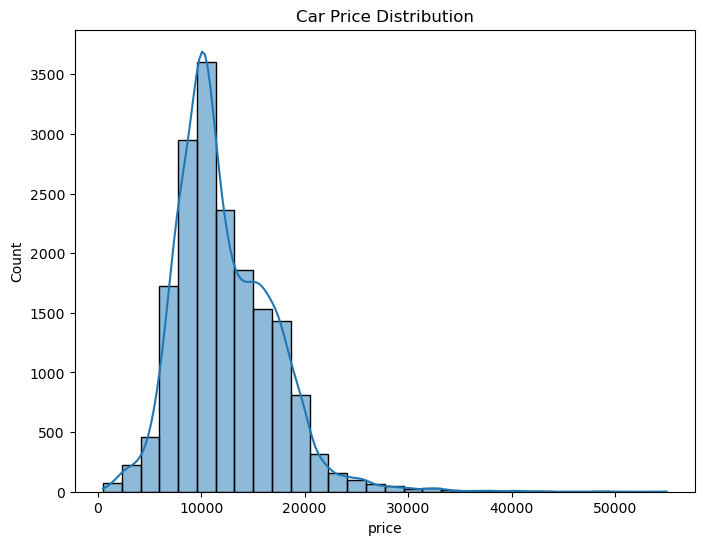

<Axes: >

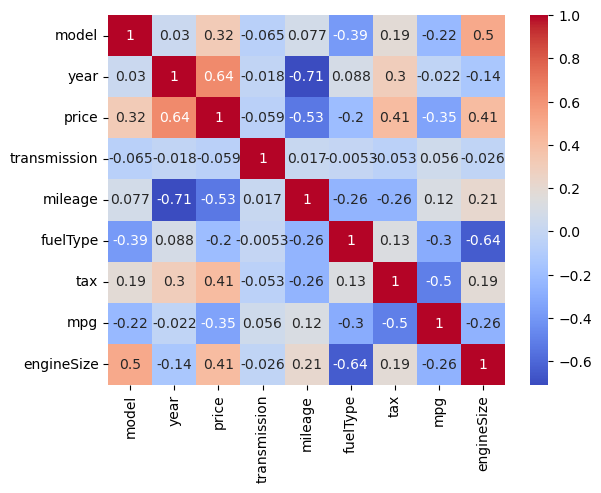

In [10]:
plt.figure(figsize=(8,6))
sns.histplot(df['price'], bins=30, kde=True)
plt.title("Car Price Distribution")
plt.show()

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")


In [11]:
X = df[['year','mileage','tax','mpg','engineSize','model','transmission','fuelType']]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [12]:
model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


R2 Score: 0.7056898090850849
RMSE: 2568.916705215376


In [15]:
X = df[['year','mileage','tax','mpg','engineSize','model','transmission','fuelType']]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [16]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Linear Regression R2:", r2_score(y_test, y_pred_lr))
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))


Linear Regression R2: 0.7056898090850849
Linear Regression RMSE: 2568.916705215376


In [2]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor   # ✅ Correct Import
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_csv("ford.csv")
df = df.dropna().drop_duplicates()

# Convert categorical to numeric
df['model'] = df['model'].astype('category').cat.codes
df['transmission'] = df['transmission'].astype('category').cat.codes
df['fuelType'] = df['fuelType'].astype('category').cat.codes

# Features & Target
X = df[['year','mileage','tax','mpg','engineSize','model','transmission','fuelType']]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# XGBoost
xgb = XGBRegressor(n_estimators=300, learning_rate=0.1, max_depth=6, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

# Compare Results
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "R2 Score": [r2_score(y_test, y_pred_lr),
                 r2_score(y_test, y_pred_rf),
                 r2_score(y_test, y_pred_xgb)],
    "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred_lr)),
             np.sqrt(mean_squared_error(y_test, y_pred_rf)),
             np.sqrt(mean_squared_error(y_test, y_pred_xgb))]
})

print(results)


               Model  R2 Score         RMSE
0  Linear Regression  0.705690  2568.916705
1      Random Forest  0.925846  1289.477420
2            XGBoost  0.936546  1192.821445


In [3]:
xgb = XGBRegressor(n_estimators=300, learning_rate=0.1, max_depth=6, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("XGBoost R2:", r2_score(y_test, y_pred_xgb))
print("XGBoost RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))


XGBoost R2: 0.9365464448928833
XGBoost RMSE: 1192.8214451459196


In [4]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "R2 Score": [r2_score(y_test, y_pred_lr),
                 r2_score(y_test, y_pred_rf),
                 r2_score(y_test, y_pred_xgb)],
    "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred_lr)),
             np.sqrt(mean_squared_error(y_test, y_pred_rf)),
             np.sqrt(mean_squared_error(y_test, y_pred_xgb))]
})

print(results)


               Model  R2 Score         RMSE
0  Linear Regression  0.705690  2568.916705
1      Random Forest  0.925846  1289.477420
2            XGBoost  0.936546  1192.821445


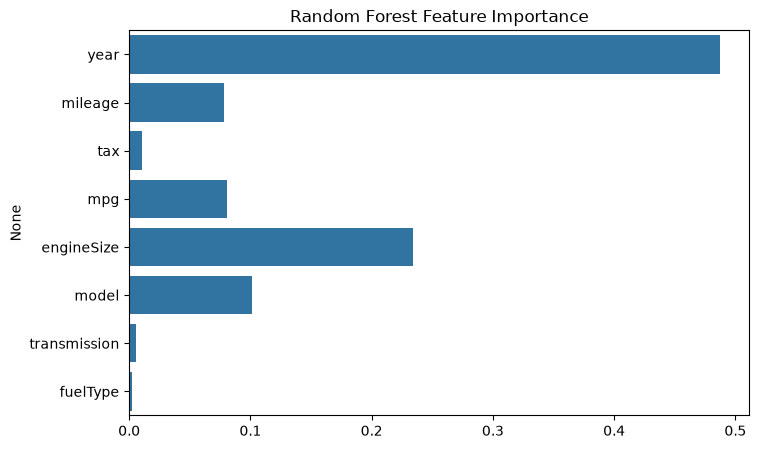

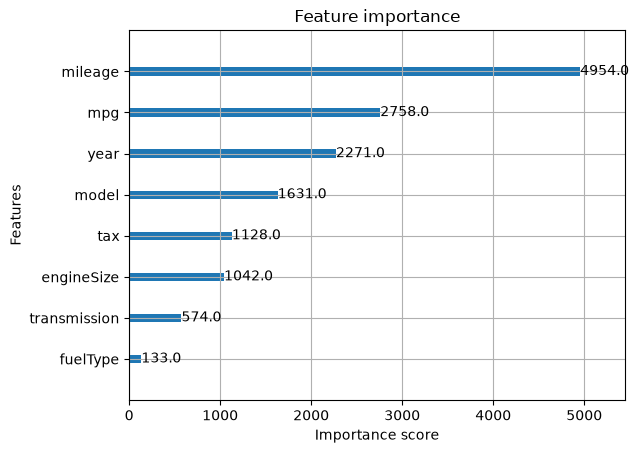

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Random Forest Feature Importance
importances = rf.feature_importances_
features = X.columns

plt.figure(figsize=(8,5))
sns.barplot(x=importances, y=features)
plt.title("Random Forest Feature Importance")
plt.show()

# XGBoost Feature Importance
from xgboost import plot_importance
plot_importance(xgb, max_num_features=10, importance_type='weight')
plt.show()


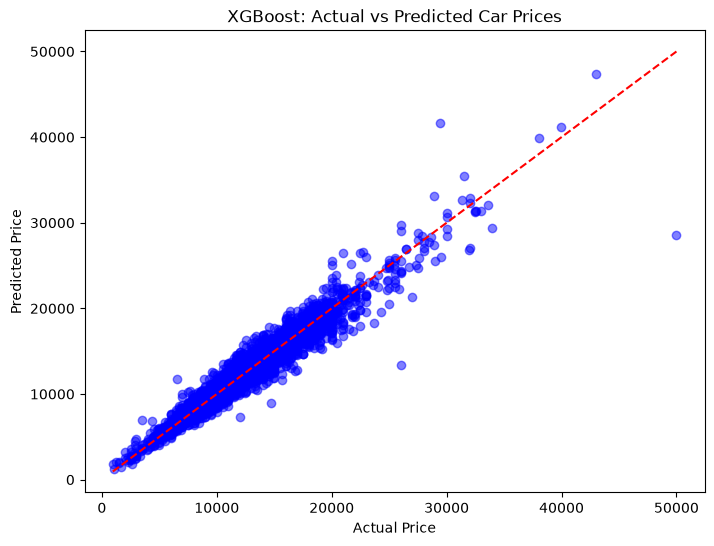

In [6]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_xgb, alpha=0.5, color="blue")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("XGBoost: Actual vs Predicted Car Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect fit line
plt.show()


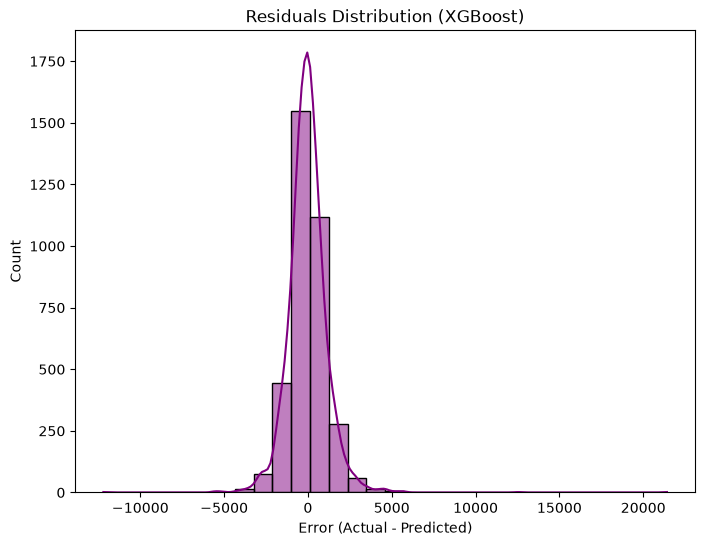

In [7]:
residuals = y_test - y_pred_xgb

plt.figure(figsize=(8,6))
sns.histplot(residuals, bins=30, kde=True, color="purple")
plt.title("Residuals Distribution (XGBoost)")
plt.xlabel("Error (Actual - Predicted)")
plt.show()


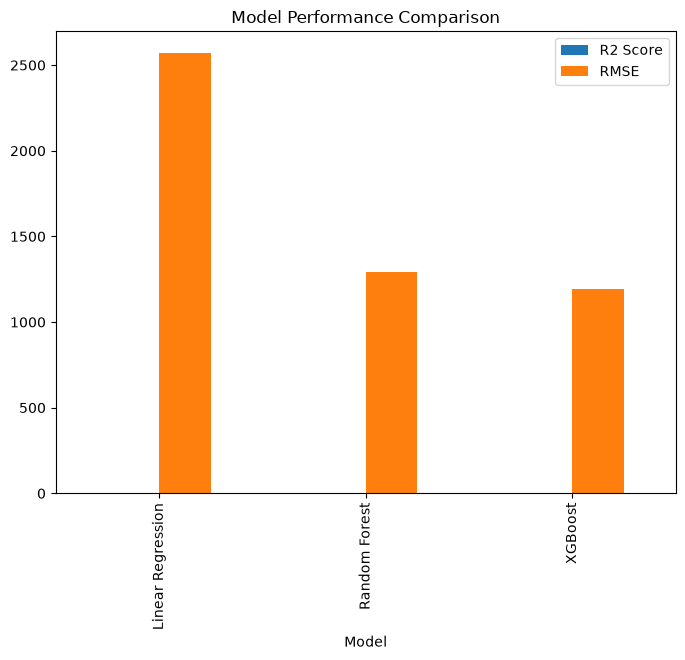

In [8]:
results.plot(x="Model", y=["R2 Score","RMSE"], kind="bar", figsize=(8,6))
plt.title("Model Performance Comparison")
plt.show()
